<a href="https://colab.research.google.com/github/OlorteguiKevin/lab09/blob/develop/Lab09_MD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

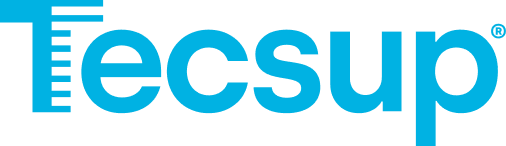

# DEPARTAMENTO DE TECNOLOGÍA DIGITAL Y GESTIÓN
## Carrera de Big Data y Ciencia de Datos
# LABORATORIO 9

## Integrantes:
- Joshua Jian Cora Salazar
- Kevin Estiben Olortegui Perez

Indicaciones:
- El trabajo en su totalidad debe ser hecho en un notebook de ‘Jupyter’.
- Cree una cabecera que lleve por título el tema de la semana y debajo de él coloque un ‘Markdown’ con su nombre y apellido.
- Ejecute su notebook, grábelo, descárguelo como HTML, conviértalo a PDF y suba ambos archivos en el apartado que el docente indique.

 En esta ocasión se hará la implementación de una red neuronal de clasificación y otra red neuronal
convolucional, tomando un 20% de datos de prueba para ambos casos:

a. Mediante la base a datos de cáncer de mama alojados en el repositorio UCI Machine Learning Repository (https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+%28original%29) y utilizando la librería de Python ‘scikit-learn’, cree una red neuronal para clasificar a un paciente como canceroso o no canceroso de tal forma que obtenga el mayor valor de accuracy. Para ello, debe realizar el preprocesamiento de la información e ir ajustando la red neuronal con los parámetros requeridos como la cantidad de capas ocultas y neuronas por cada capa oculta, el número de iteraciones, la función de activación, el método para minimizar la función de error, entre otros.

In [1]:
# Importamos las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                            confusion_matrix, ConfusionMatrixDisplay)
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.utils import to_categorical

# Configuración general
SEED = 42
np.random.seed(SEED)
plt.style.use('ggplot')

# PARTE 1: RED NEURONAL PARA CLASIFICACIÓN (CÁNCER DE MAMA)

In [2]:
# Función para la carga y preprocesamiento
def cargar_datos_clasificacion():
    """Carga y prepara el dataset de cáncer de mama"""
    try:
        # Cargar desde scikit-learn
        datos = load_breast_cancer()
        X = pd.DataFrame(datos.data, columns=datos.feature_names)
        y = pd.Series(datos.target).map({0:1, 1:0})  # 1: Maligno, 0: Benigno
        print("✅ Dataset cargado | Forma:", X.shape)
        return X, y

    except Exception as e:
        print(f"❌ Error: {str(e)}")
        return None, None

In [3]:
# Función para el modelado
def crear_modelo_clasificacion():
    """Crea MLPClassifier optimizado"""
    return MLPClassifier(
        hidden_layer_sizes=(50, 25),  # 2 capas ocultas
        activation='relu',
        solver='adam',
        max_iter=1000,
        early_stopping=True,
        random_state=SEED
    )

In [4]:
# Funci+on para la evaluación del modelo
def evaluar_modelo_clasificacion(modelo, X_test, y_test):
    """Genera métricas y matriz de confusión"""
    y_pred = modelo.predict(X_test)

    # Reporte de clasificación
    print("\n🔍 Reporte de Clasificación:")
    print(classification_report(y_test, y_pred, target_names=['Benigno', 'Maligno']))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benigno', 'Maligno'])
    disp.plot(cmap='Blues')
    plt.title("Matriz de Confusión")
    plt.show()

# PARTE 2: RED CONVOLUCIONAL (MNIST)

In [5]:
# Carga y preparación de datos
def preprocesar_mnist():
    """Preprocesa el dataset MNIST"""
    (X_train, y_train), (X_test, y_test) = mnist.load_data()

    # Normalización y reshape
    X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

    # One-hot encoding
    y_train = to_categorical(y_train)
    y_test = to_categorical(y_test)

    print("\n📊 Dataset MNIST:")
    print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
    return X_train, X_test, y_train, y_test

In [7]:
# Arquitectura CNN
def crear_cnn():
    """Crea modelo convolucional"""
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [8]:
# Entrenamiento y evaluación
def entrenar_cnn(modelo, X_train, y_train, epochs=10):
    """Entrena la CNN y muestra progreso"""
    historia = modelo.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=128,
        verbose=1
    )

    # Gráfico de precisión
    plt.plot(historia.history['accuracy'], label='Entrenamiento')
    plt.plot(historia.history['val_accuracy'], label='Validación')
    plt.title('Evolución de la Precisión')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()
    plt.show()


PARTE 1: CLASIFICACIÓN DE CÁNCER DE MAMA
✅ Dataset cargado | Forma: (569, 30)

🔍 Reporte de Clasificación:
              precision    recall  f1-score   support

     Benigno       0.91      0.93      0.92        72
     Maligno       0.88      0.83      0.85        42

    accuracy                           0.89       114
   macro avg       0.89      0.88      0.89       114
weighted avg       0.89      0.89      0.89       114



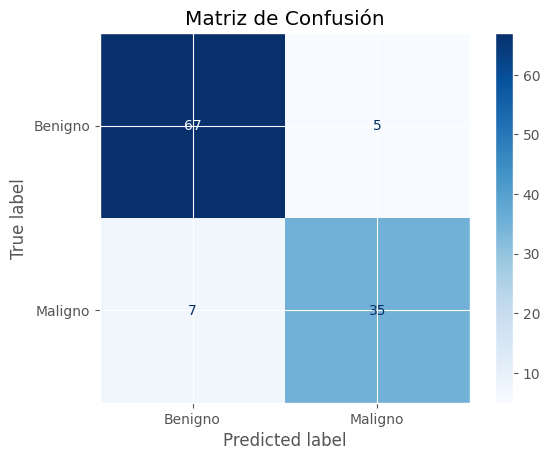


PARTE 2: RED CONVOLUCIONAL (MNIST)
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📊 Dataset MNIST:
Train shape: (60000, 28, 28, 1) | Test shape: (10000, 28, 28, 1)

🧠 Arquitectura de la CNN:


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 29s 71ms/step - accuracy: 0.8533 - loss: 0.5099 - val_accuracy: 0.9692 - val_loss: 0.1083
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 67ms/step - accuracy: 0.9739 - loss: 0.0908 - val_accuracy: 0.9806 - val_loss: 0.0711
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.9853 - loss: 0.0527 - val_accuracy: 0.9824 - val_loss: 0.0580
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.9884 - loss: 0.0388 - val_accuracy: 0.9822 - val_loss: 0.0572
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.9916 - loss: 0.0284 - val_accuracy: 0.9829 - val_loss: 0.0558
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.9939 - loss: 0.0211 - val_accuracy: 0.9845 - val_loss: 0.0548
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - accuracy: 0.9956 - loss: 0.0157 - val_accuracy: 0.9871 - val_loss: 0.0475
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 66ms/step - accuracy: 0.9970 - loss: 0.0105 - 

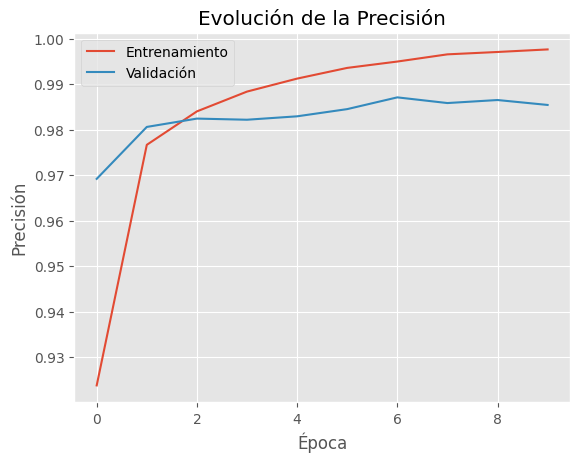


🎯 Precisión en prueba: 98.65%


In [9]:
if __name__ == "__main__":
    # Clasificación
    print("\n" + "="*50)
    print("PARTE 1: CLASIFICACIÓN DE CÁNCER DE MAMA")
    print("="*50)

    X, y = cargar_datos_clasificacion()
    if X is not None:
        # División de datos
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=SEED
        )

        # Escalado
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Modelado
        modelo_clf = crear_modelo_clasificacion()
        modelo_clf.fit(X_train, y_train)

        # Evaluación
        evaluar_modelo_clasificacion(modelo_clf, X_test, y_test)

    # Red Convolucional
    print("\n" + "="*50)
    print("PARTE 2: RED CONVOLUCIONAL (MNIST)")
    print("="*50)

    X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = preprocesar_mnist()
    cnn = crear_cnn()
    print("\n🧠 Arquitectura de la CNN:")
    cnn.summary()

    entrenar_cnn(cnn, X_train_cnn, y_train_cnn, epochs=10)

    # Evaluación final
    test_loss, test_acc = cnn.evaluate(X_test_cnn, y_test_cnn, verbose=0)
    print(f"\n🎯 Precisión en prueba: {test_acc:.2%}")